# Simulation of a positron-induced Muon Source

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<center>
    <img src="Feynman_Diagram.svg" width="400" style="filter: invert(100%)">
</center>

\begin{split}
iM &= \overline{U}_{r'}(k) (ie\gamma^{\mu}) V_{s'}(k') \left( \frac{-i\eta_{\mu\nu}}{s} \right) \overline{V}_{s}(p') (ie\gamma^{\nu}) U_{r}(p) \\
   &= \frac{ie^2}{s} (\overline{U}_{r'}(k) \gamma^{\mu} V_{s'}(k') \overline{V}_{s}(p') \gamma_{\mu} U_{r}(p))
\end{split}


$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$
$|\overline{M}|^2 = \frac{1}{4} \sum_{spins} M M^* = \frac{e^4}{4 s^2} Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'-m) \gamma_\mu)$

$Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) = 4 (k^\mu k'^\nu + k^\nu k'^\mu - (k \cdot k' + m_\mu^2) \eta^{\nu\mu})$

$Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'+m) \gamma_\mu) = 4 (p_\mu p'_\nu + p_\nu p'_\mu - (p \cdot p' + m_e^2) \eta_{\nu\mu})$


(Note: $m_\mu^2$ is not Einstein indexing)

$|\overline{M}|^2 = \frac{8 e^4}{s^2} ((k \cdot p)(k' \cdot p') + (k \cdot p')(k' \cdot p) + m_e^2 (k \cdot k') + m_\mu^2 (p \cdot p') + 2 m_e^2 m_\mu^2)$

$m_e$ negligible ?

Kinematic

$ s = (p + p')^2 = 2 m_e^2 + 2 p \cdot p' \Rightarrow p \cdot p' = \frac{s}{2} - m_e^2 $

$ k \cdot k' = \frac{s}{2} - m_\mu^2$

$ p \cdot k = $

$ p \cdot k' = $

If $m_e = 0$

$\left( \frac{d\sigma}{d\omega} \right)_{CM} = \frac{e^4}{64 \pi^2 s} \sqrt{\left(1 - \frac{4 m_\mu^2}{s} \right)} \left(\left(1 + \frac{4 m_\mu^2}{s} \right) + \left(1 - \frac{4 m_\mu^2}{s} \right) \cos{\theta}^2 \right) $

$(p, 0, 0, p)$

$p_\mu p^\mu = m_\gamma^2 = 0 = E^2 - p^2$

Threshold sqrt(s) is: 0.211316751 GeV
sqrt(s) fixed at: 0.23244842610000002 GeV,  10.0 % above threshold
Beam energy:  52.86874707233067 GeV


<function matplotlib.pyplot.show(close=None, block=None)>

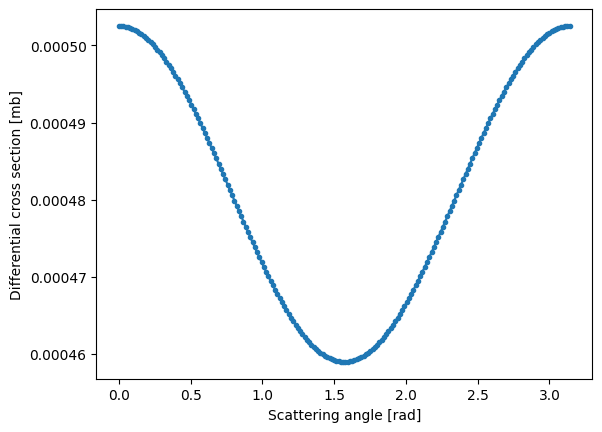

In [2]:
mass_e = 0.00051099895069 # GeV
mass_mu = 0.1056583755 # GeV
alpha = 1/137
conversion_factor = 0.3894      # this is equal to (hbar * c)^2 expressed in mbarn * GeV


def cross_section(s, theta):
    ratio = 4 * mass_mu**2 / s
    return ((np.pi * alpha**2 )/ (2 * s)) * np.sqrt(1 - ratio) * (1 + ratio + (1 - ratio) * np.cos(theta)**2)

def cross_section_norm(s, cos):     # check normalization
    ratio = 4 * mass_mu**2 / s
    beta = np.sqrt(1 - ratio)
    return 3 / (4*(3 - beta**2)) * (1 + cos**2 + (1 - beta**2) * (1 - cos**2))

E_threshold = 2*mass_mu     # threshold
print('Threshold sqrt(s) is:', E_threshold, 'GeV')
E_percent_increase = 0.1
E_fixed = E_threshold * (1 + E_percent_increase)    # should be greater than 4 mass_mu**2
print('sqrt(s) fixed at:', E_fixed, 'GeV, ', E_percent_increase * 100, r'% above threshold')
s = E_fixed**2

beam_energy = (s - 2 * mass_e**2) / (2 * mass_e)
print('Beam energy: ', beam_energy, 'GeV')

l = np.linspace(0, np.pi, 200, endpoint=True)
plt.plot(l, cross_section(s, l) * conversion_factor, marker=".")
plt.xlabel('Scattering angle [rad]')
plt.ylabel('Differential cross section [mb]')
plt.show

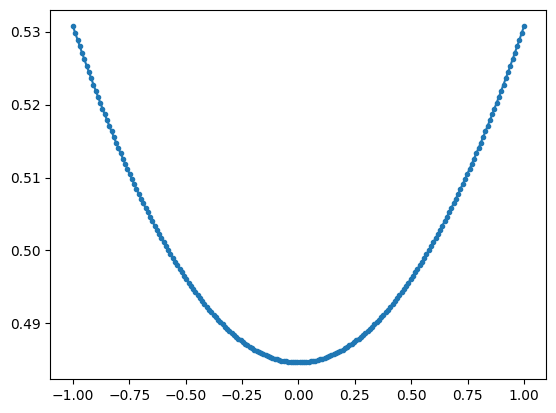

In [3]:
cos_linspace = np.linspace(-1, 1, 200, endpoint=True)
plt.plot(cos_linspace, cross_section_norm(s, cos_linspace), marker=".")


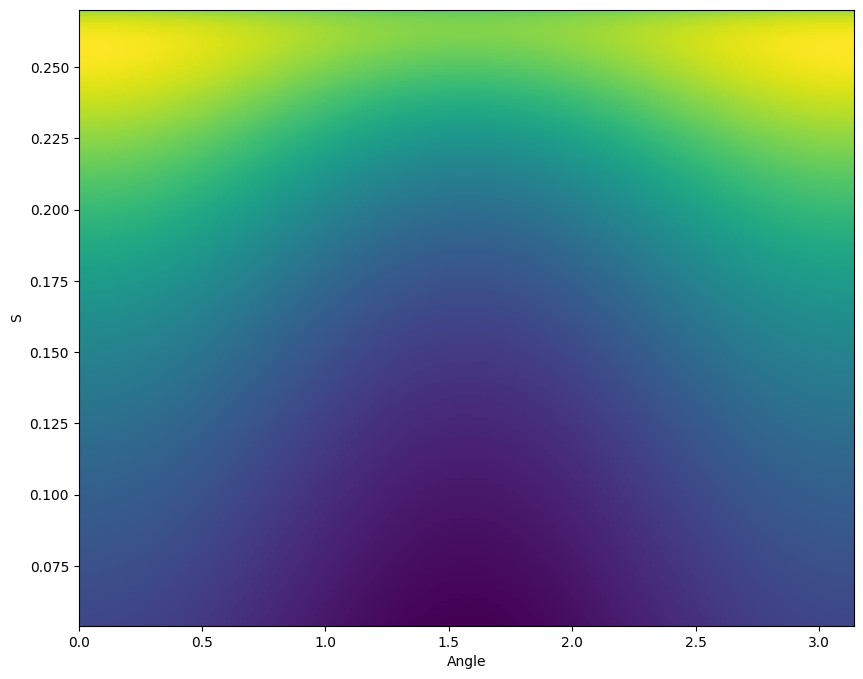

In [4]:
s_space = np.linspace(s, 5 * s, 200, endpoint=True)

xv, yv = np.meshgrid(l, s_space)

plt.figure(figsize=(10, 8))
plt.imshow(cross_section(yv, xv), extent=[0, np.pi, s, 5*s], aspect='auto')
plt.xlabel("Angle")
plt.ylabel("S")
plt.show()

94248


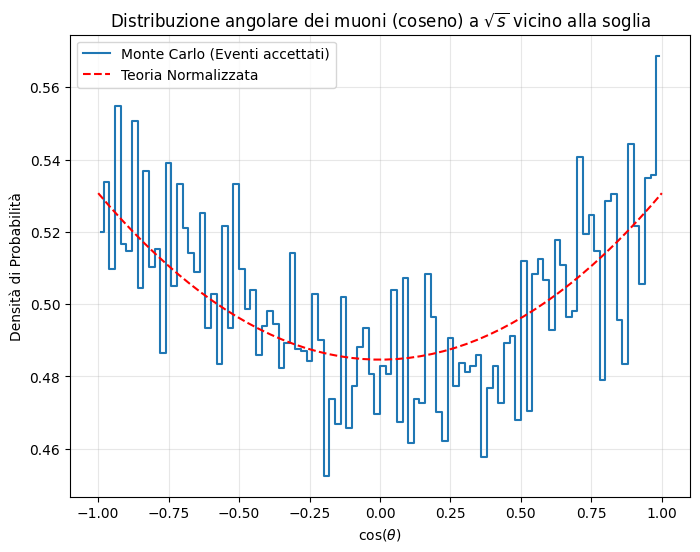

In [5]:
n = 100000
u = np.random.uniform(-1, 1, n)
r = np.random.uniform(0, cross_section_norm(s, 1), n)
v = u[r < cross_section_norm(s, u)]
print(len(v))

# Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$ E_{e^+}=\frac{s-2m_e^2}{2m_e}$

$p_{e^+}=\sqrt{E_{e^+}^2-m_e^2}$

$\beta=\frac{p_{e^+}}{E_{e^+}+m_e}=\frac{v}{c}$

$\gamma=\frac{E_{e^+}+m_e}{\sqrt {s}}=\frac{1}{\sqrt{1-\beta^2}}$

$p_{\mu}=\sqrt{\frac{s}{4}-m_{\mu}^2}$

$p_{x,CM}=p_{\mu}\sin\theta\cos\phi$

$p_{y,CM}=p_{\mu}\sin\theta\sin\phi$

$p_{z,CM}=p_{\mu}\cos\theta$

$E_{CM}=\frac{\sqrt{s}}{2}$

$ E_{lab} = \gamma (E_{CM}+\beta p_{z,CM})$

$ p_{z,lab} = \gamma(p_{z,CM}+\beta E_{CM})$

$ p_{x,lab} = p_{x,CM}$

$ p_{y,lab} = p_{y,CM}$

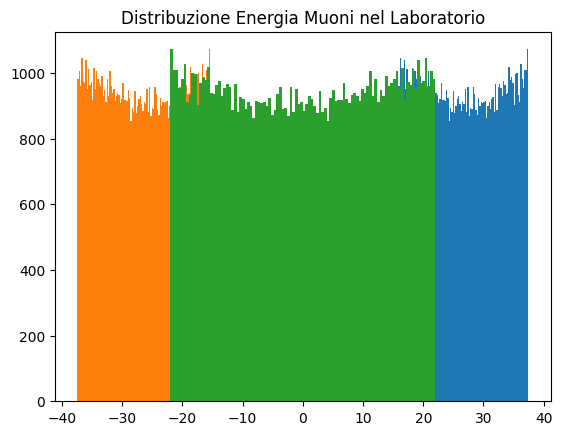

In [6]:
E_pos = (s - 2 * mass_e**2) / (2 * mass_e)
p_pos = np.sqrt(E_pos**2 - mass_e**2)
gamma = (E_pos + mass_e) / np.sqrt(s)
beta = p_pos / (E_pos + mass_e)

phi = np.random.uniform(0, 2*np.pi, len(v))
p_mod = np.sqrt(s/4 - mass_mu**2)
px_cm_1 = p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_1 = p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_1 = p_mod * v
E_cm_1 = np.sqrt(s)/2

px_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_2 = -1 * p_mod * v
E_cm_2 = np.sqrt(s)/2

px_lab_1=px_cm_1
py_lab_1=py_cm_1
pz_lab_1 = gamma * (pz_cm_1 + beta * E_cm_1)
E_lab_1 = gamma * (E_cm_1 + beta * pz_cm_1)

px_lab_2=px_cm_2
py_lab_2=py_cm_2
pz_lab_2 = gamma * (pz_cm_2 + beta * E_cm_2)
E_lab_2 = gamma * (E_cm_2 + beta * pz_cm_2)

plt.hist(E_lab_1, bins=100)
plt.hist(-1.0* E_lab_2, bins=100)
plt.hist(E_lab_2 - E_lab_1, bins=100)
#plt.scatter(E_lab_1, E_lab_2, marker=".")
plt.title("Distribuzione Energia Muoni nel Laboratorio")
plt.show()


(array([  255.,   566.,   895.,  1273.,  1597.,  1926.,  2204.,  2632.,
         2882.,  3325.,  3662.,  3947.,  4330.,  4709.,  5115.,  5808.,
         6598.,  7863., 10230., 24431.]),
 array([8.26860050e-06, 1.08596467e-04, 2.08924334e-04, 3.09252201e-04,
        4.09580068e-04, 5.09907935e-04, 6.10235801e-04, 7.10563668e-04,
        8.10891535e-04, 9.11219402e-04, 1.01154727e-03, 1.11187514e-03,
        1.21220300e-03, 1.31253087e-03, 1.41285874e-03, 1.51318660e-03,
        1.61351447e-03, 1.71384234e-03, 1.81417020e-03, 1.91449807e-03,
        2.01482594e-03]),
 <BarContainer object of 20 artists>)

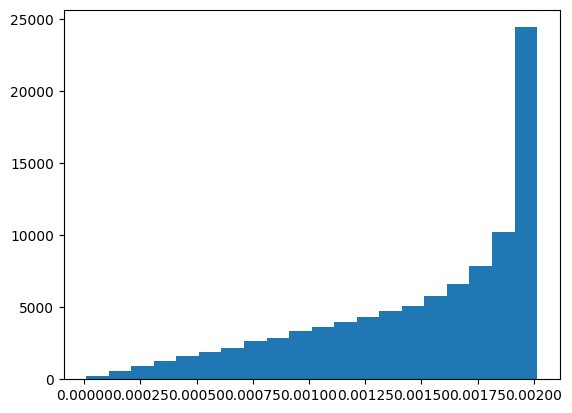

In [7]:
plt.hist(np.arccos(pz_lab_1 / np.sqrt(px_cm_1 ** 2 + py_cm_1 ** 2 + pz_lab_1 ** 2)), bins=20)

(array([  177.,   606.,   915.,  1243.,  1659.,  1892.,  2316.,  2612.,
         2951.,  3286.,  3686.,  3971.,  4391.,  4814.,  5177.,  5920.,
         6516.,  7898., 10171., 24047.]),
 array([6.73372576e-06, 1.07138336e-04, 2.07542947e-04, 3.07947557e-04,
        4.08352168e-04, 5.08756779e-04, 6.09161389e-04, 7.09566000e-04,
        8.09970610e-04, 9.10375221e-04, 1.01077983e-03, 1.11118444e-03,
        1.21158905e-03, 1.31199366e-03, 1.41239827e-03, 1.51280288e-03,
        1.61320749e-03, 1.71361211e-03, 1.81401672e-03, 1.91442133e-03,
        2.01482594e-03]),
 <BarContainer object of 20 artists>)

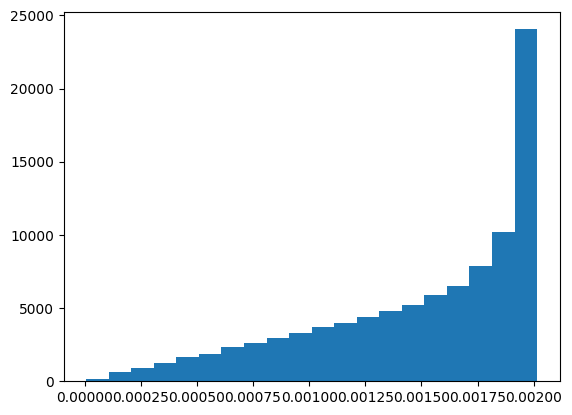

In [8]:
plt.hist(np.arccos(pz_lab_2 / np.sqrt(px_cm_2 ** 2 + py_cm_2 ** 2 + pz_lab_2 ** 2)), bins=20)

In [9]:
data = np.column_stack([E_lab_1, px_lab_1, py_lab_1, pz_lab_1, E_lab_2, px_lab_2, py_lab_2, pz_lab_2])

np.savetxt("muons_lab.txt", data)

column_names = ["E_mu+_lab", "px_mu+_lab", "py_mu+_lab", "pz_mu+_lab", "E_mu-_lab", "px_mu-_lab", "py_mu-_lab", "pz_mu-_lab"]
df = pd.read_csv("muons_lab.txt",sep=r'\s+', names=column_names)

df

,E_mu+_lab,px_mu+_lab,py_mu+_lab,pz_mu+_lab,E_mu-_lab,px_mu-_lab,py_mu-_lab,pz_mu-_lab
0,26.273760,-0.023035,0.042583,26.273503,26.595498,0.023035,-0.042583,26.595244
1,17.255799,-0.005827,0.026111,17.255455,35.613459,0.005827,-0.026111,35.613292
2,28.703713,-0.046373,-0.009713,28.703479,24.165545,0.046373,0.009713,24.165268
3,34.825605,0.029141,0.011580,34.825430,18.043653,-0.029141,-0.011580,18.043317
4,30.420933,0.030552,-0.033223,30.420716,22.448325,-0.030552,0.033223,22.448031
...,...,...,...,...,...,...,...,...
94243,34.709419,0.025961,0.018621,34.709244,18.159839,-0.025961,-0.018621,18.159504
94244,29.171731,-0.012211,0.045282,29.171502,23.697527,0.012211,-0.045282,23.697245
94245,15.539311,-0.000078,-0.007044,15.538950,37.329947,0.000078,0.007044,37.329797
94246,35.689933,-0.017875,-0.019208,35.689767,17.179325,0.017875,0.019208,17.178980


Text(0, 0.5, '$\\phi$ [rad]')

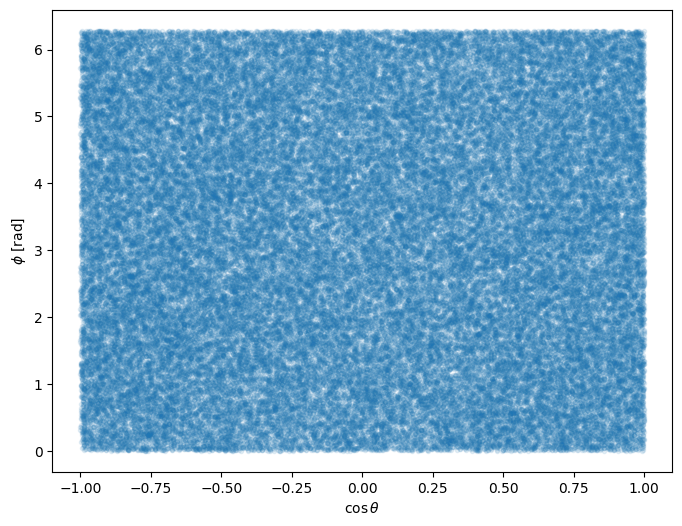

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(v, phi, marker=".", alpha=0.1)
plt.xlabel(r"$\cos{\theta}$")
plt.ylabel(r"$\phi$ [rad]")

Text(0, 0.5, '$\\phi$ [rad]')

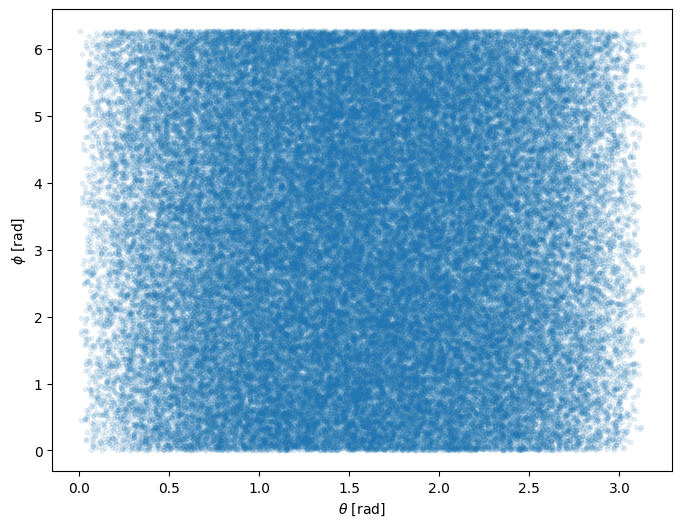

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(np.arccos(v), phi, marker=".", alpha=0.1)
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\phi$ [rad]")

In [12]:
#total cross section integrating over solid angle
cross_section_tot = ((2 * np.pi * alpha**2) / (3 * s)) * beta * (3 - beta**2) * conversion_factor
print('The total cross section is:', cross_section_tot, 'mbarn')

The total cross section is: 0.0016083856965234868 mbarn


In [13]:
# point 6
d = 3                       # cm
rate = 10**6                # Hz

uma = 1.660539e-24          # unitò di massa atomica in g
B = 9.0121831               # atomic weight del berillio in uma
rho = 1.845                 # densità del berillio in g/cm^3
n_be = rho / (uma * B)         # densità atomica del berillio

P = n_be * d * cross_section_tot * 10**(-27)       # convertendo la cross section da mbarn a cm**2
T = 7 * 24 * 3600           # s

E = T * rate * P
weight = E / len(v)
print(E)
print(len(v))

print('The conversion factor is:', weight)

359782.90427444497
94248
The conversion factor is: 3.8174062502593684


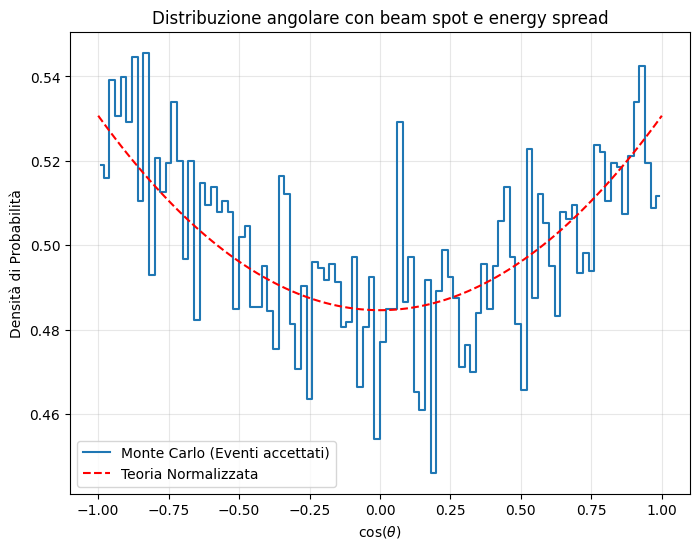

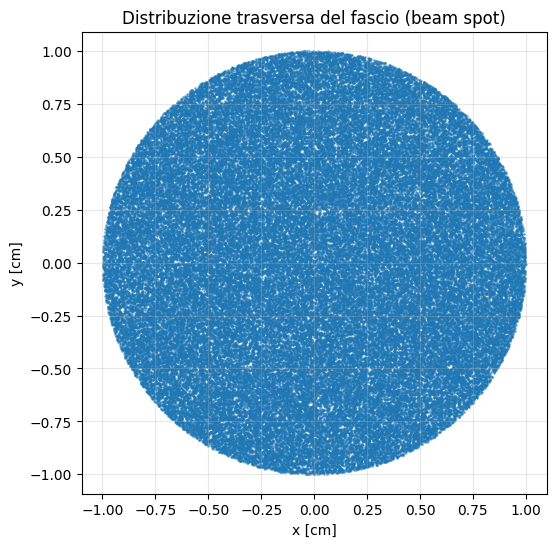

In [14]:
R = 1.0  
alpha = np.random.uniform(0, 2*np.pi, n)
rho = R * np.sqrt(np.random.uniform(0,1,n))
x = rho * np.cos(alpha)
y = rho * np.sin(alpha)

sigmaE=0.5 #width
E=np.random.normal(beam_energy, sigmaE, n)

m_e = 0.000511  # GeV
s = 2 * m_e * (E + m_e) #in lab frame

u_new = np.random.uniform(-1, 1, n)
r_new = np.random.uniform(0, cross_section_norm(s, 1), n)
v_new = u_new[r_new < cross_section_norm(s, u_new)]


# Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v_new, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
s_mean = np.mean(s)#curva teorica “di riferimento”, confronto visivo con la curva teorica serve una singola curva
cos_range = np.linspace(-1, 1, 100)
plt.plot(cos_range, cross_section_norm(s_mean, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare con beam spot e energy spread")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot del beam spot (x,y)
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, alpha=0.5)
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Distribuzione trasversa del fascio (beam spot)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

In [15]:
# Energia soglia per generare muoni
E_th = ((2*mass_mu)**2 - 2 * m_e**2) / (2*m_e)  # GeV

# Parametri target
L = 6.0   # lunghezza target in cm (usato nel paper del prof)
X0 = 35.3 # lunghezza di radiazione del Be in cm
E0 = E_th * np.exp(L / X0)
print(f"Nominal beam energy: {E0:.2f} GeV")

z = np.random.uniform(0, L, n)  # posizione casuale lungo il target
E_beam = E0 * np.exp(-z / X0)  # energia effettiva al punto z

data = pd.DataFrame({"x_cm": x,"y_cm": y, "z_cm": z,"E_beam_GeV": E_beam})
data.to_csv("simulated_muon_beam.csv", index=False)
data

Nominal beam energy: 51.79 GeV


,x_cm,y_cm,z_cm,E_beam_GeV
0,-0.673738,0.042849,0.178093,51.527439
1,-0.801958,-0.079176,1.048779,50.272045
2,-0.361869,-0.505213,2.972414,47.605831
3,0.426141,0.758067,4.013836,46.221876
4,-0.923304,-0.145952,4.211345,45.963980
...,...,...,...,...
99995,0.354299,-0.078233,3.284564,47.186718
99996,-0.638273,0.244453,3.519425,46.873813
99997,0.624867,-0.768515,5.983453,43.713487
99998,-0.194809,-0.050117,0.117450,51.616037


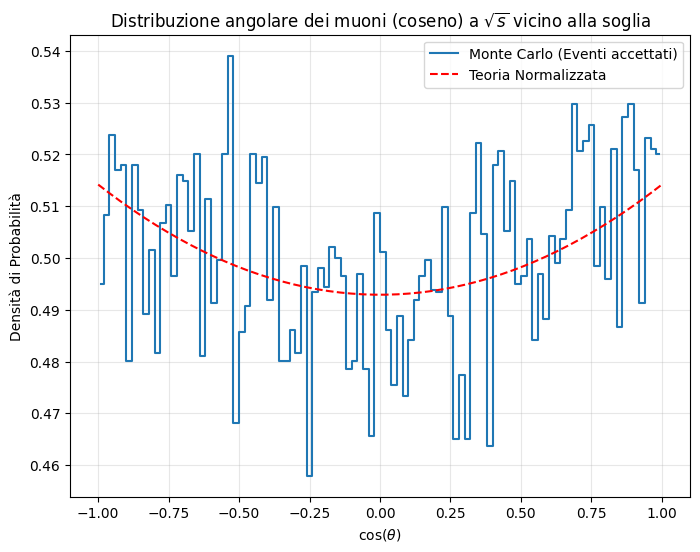

In [16]:
# Genera angoli nel CM usando s_z
s_z = 2 * m_e**2 + 2 * m_e * E_beam

u_z = np.random.uniform(-1, 1, n)
r_z = np.random.uniform(0, cross_section_norm(s_z, 1), n)
v_z = u_z[r_z < cross_section_norm(s_z, u_z)]

plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v_z, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
s_z_mean = np.mean(s_z)
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s_z_mean, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Effettua il Boost nel Lab usando E_z e s_z